# ☄️ NEO Hazard Predictor
### Full pipeline: EDA → Logistic Regression → MLP → XGBoost + SHAP

In [ ]:
!pip install shap xgboost --quiet

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

print("All imports successful.")

All imports successful.


## 2. Load & inspect data

In [ ]:
df = pd.read_csv('neo.csv')
print(f"Shape: {df.shape}")
df.info()

Shape: (90836, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [ ]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


## 3. Clean data

In [ ]:
# orbiting_body has only one unique value (Earth) — useless for prediction
print("orbiting_body unique values:", df["orbiting_body"].unique())
df = df.drop("orbiting_body", axis=1)

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Class distribution
print("\nClass distribution:")
print(df["hazardous"].value_counts())
print(df["hazardous"].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

orbiting_body unique values: ['Earth']

Missing values per column:
id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

Class distribution:
hazardous
False    81996
True      8840
Name: count, dtype: int64
hazardous
False    90.3%
True      9.7%
Name: proportion, dtype: object


## 4. Exploratory Data Analysis (EDA)

In [ ]:
df.describe().round(3)

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000,90836.000,90836.000,9.083600e+04,90836.000
mean,1.438288e+07,0.127,0.285,48066.919,3.706655e+07,23.527
std,2.087202e+07,0.299,0.667,25293.297,2.235204e+07,2.894
min,2.000433e+06,0.001,0.001,203.346,6.745533e+03,9.230
25%,3.448110e+06,0.019,0.043,28619.021,1.721082e+07,21.340
50%,3.748362e+06,0.048,0.108,44190.118,3.784658e+07,23.700
75%,3.884023e+06,0.143,0.321,62923.605,5.654900e+07,25.700
max,5.427591e+07,37.893,84.731,236990.128,7.479865e+07,33.200


In [ ]:
# Mean of key features grouped by hazard label
df.groupby("hazardous")[[
    "est_diameter_min",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude"
]].mean().round(3)

,est_diameter_min,relative_velocity,miss_distance,absolute_magnitude
hazardous,,,,
False,0.109,46479.154,3.675609e+07,23.874
True,0.294,62794.337,3.994623e+07,20.308


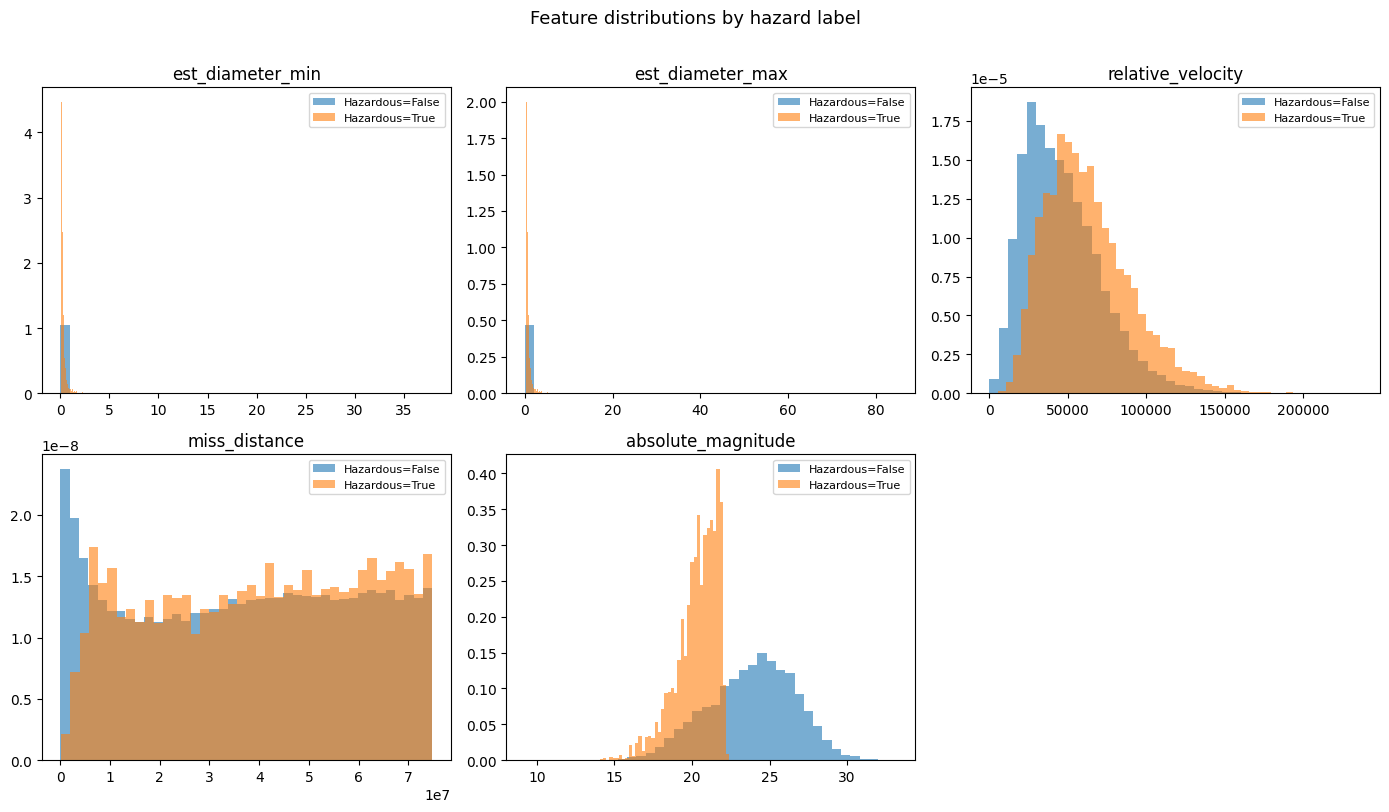

In [ ]:
# Distribution plots for each feature
features = ['est_diameter_min', 'est_diameter_max',
            'relative_velocity', 'miss_distance', 'absolute_magnitude']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    for label, grp in df.groupby("hazardous"):
        axes[i].hist(grp[feat], bins=40, alpha=0.6,
                     label=f"Hazardous={label}", density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle("Feature distributions by hazard label", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

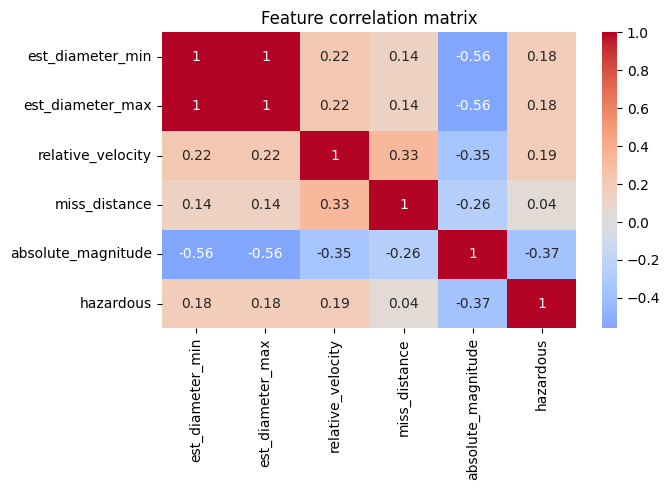

In [ ]:
import pandas as pd

# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df.copy()
corr["hazardous"] = corr["hazardous"].astype(int)
# Drop non-numeric and identifier columns before calculating correlation
corr = corr.drop(columns=['id', 'name', 'sentry_object'])
sns.heatmap(corr.corr().round(2), annot=True, cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## 5. Feature & target split

In [ ]:
FEATURES = [
    'est_diameter_min',
    'est_diameter_max',
    'relative_velocity',
    'miss_distance',
    'absolute_magnitude'
]

X = df[FEATURES]
y = df['hazardous']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {X_train_sc.shape[0]}  |  Test size: {X_test_sc.shape[0]}")

Train size: 72668  |  Test size: 18168


## 6. Evaluation helper

In [ ]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, proba=True):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_te, pred, target_names=["Not Hazardous", "Hazardous"]))

    if proba and hasattr(model, "predict_proba"):
        auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
        print(f"  ROC-AUC: {auc:.4f}")

    cm = confusion_matrix(y_te, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not Haz.", "Hazardous"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion matrix — {name}")
    plt.tight_layout()
    plt.show()
    return model

## 7. Baseline — Logistic Regression


  Logistic Regression
               precision    recall  f1-score   support

Not Hazardous       0.91      0.99      0.95     16400
    Hazardous       0.52      0.08      0.14      1768

     accuracy                           0.90     18168
    macro avg       0.71      0.54      0.54     18168
 weighted avg       0.87      0.90      0.87     18168

  ROC-AUC: 0.8812


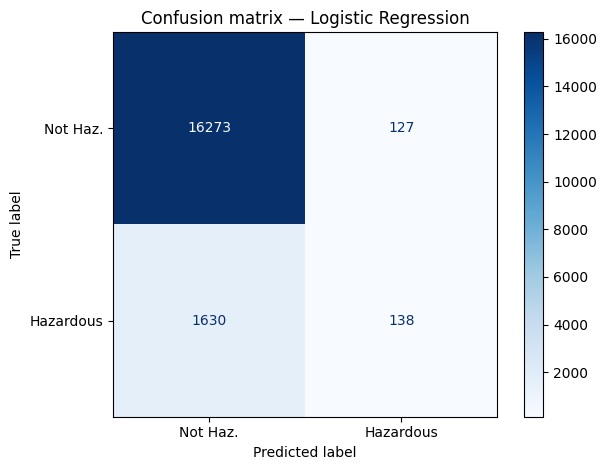

In [ ]:
lr = evaluate(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_sc, y_train, X_test_sc, y_test
)

## 8. Neural Network — MLP


  MLP Classifier
               precision    recall  f1-score   support

Not Hazardous       0.92      1.00      0.95     16400
    Hazardous       0.86      0.15      0.25      1768

     accuracy                           0.91     18168
    macro avg       0.89      0.57      0.60     18168
 weighted avg       0.91      0.91      0.89     18168

  ROC-AUC: 0.9151


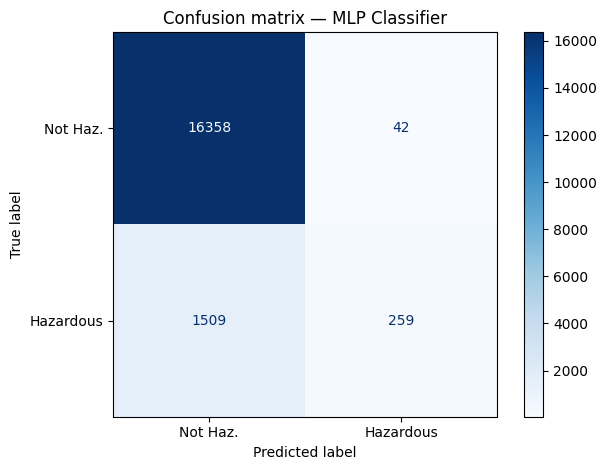

In [ ]:
mlp = evaluate(
    "MLP Classifier",
    MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        verbose=False
    ),
    X_train_sc, y_train, X_test_sc, y_test
)

## 9. XGBoost with hyperparameter tuning (GridSearchCV)

In [ ]:
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_sc, y_train)

print("\nBest params:", grid_search.best_params_)
print(f"Best CV F1:  {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1:  0.3529



  XGBoost (tuned)
               precision    recall  f1-score   support

Not Hazardous       0.92      0.99      0.96     16400
    Hazardous       0.69      0.25      0.36      1768

     accuracy                           0.92     18168
    macro avg       0.81      0.62      0.66     18168
 weighted avg       0.90      0.92      0.90     18168

  ROC-AUC: 0.9251


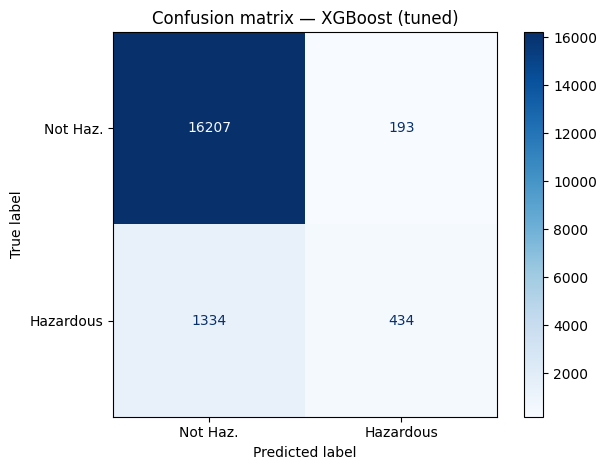

In [ ]:
best_xgb = grid_search.best_estimator_

best_xgb = evaluate(
    "XGBoost (tuned)",
    best_xgb,
    X_train_sc, y_train, X_test_sc, y_test
)

## 10. ROC curve comparison

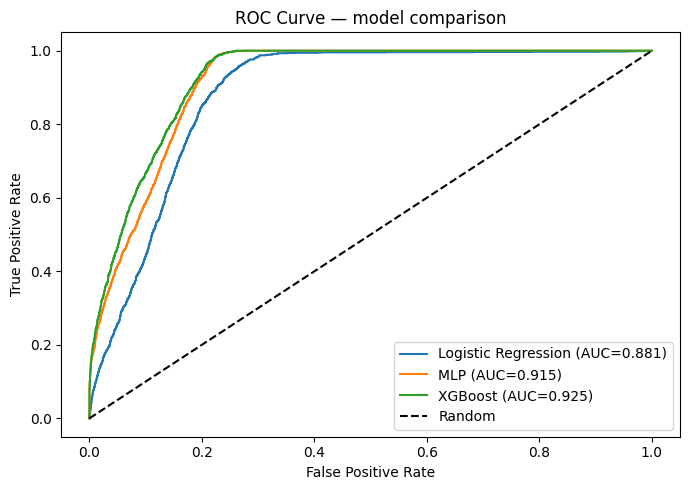

In [ ]:
plt.figure(figsize=(7, 5))

for name, model in [("Logistic Regression", lr), ("MLP", mlp), ("XGBoost", best_xgb)]:
    if hasattr(model, "predict_proba"):
        fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_sc)[:, 1])
        auc = roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1])
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — model comparison")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Model explainability with SHAP

In [ ]:
import pandas as pd

X_test_df = pd.DataFrame(X_test_sc, columns=FEATURES)

explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_df)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Mean |SHAP| per feature:")
for feat, val in zip(FEATURES, np.abs(shap_values).mean(axis=0)):
    print(f"  {feat:<25} {val:.4f}")

SHAP values shape: (18168, 5)
Mean |SHAP| per feature:
  est_diameter_min          4.0512
  est_diameter_max          0.0000
  relative_velocity         0.3306
  miss_distance             0.4621
  absolute_magnitude        2.0867


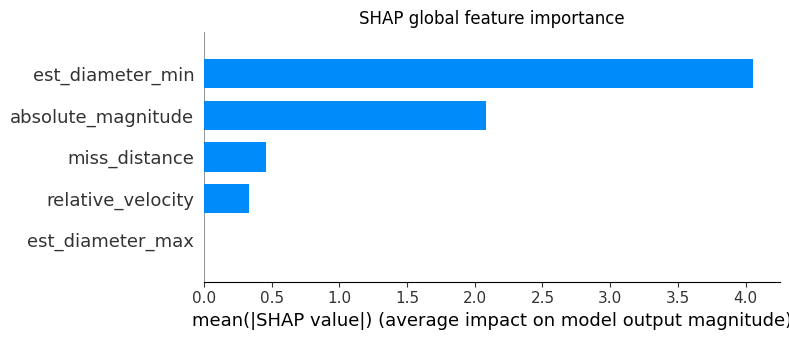

In [ ]:
# Global feature importance bar plot
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False)
plt.title("SHAP global feature importance")
plt.tight_layout()
plt.show()

In [ ]:
# Beeswarm plot — shows direction of impact
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("SHAP summary (beeswarm)")
plt.tight_layout()
plt.show()

Explaining test sample index 16
True label: Hazardous=True
Predicted probability: 0.196


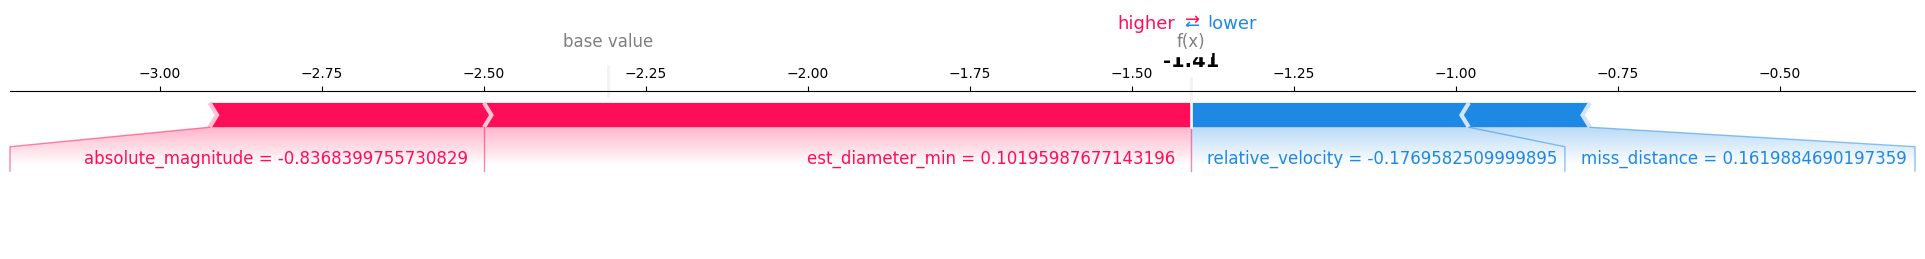

In [ ]:
# Force plot for a single prediction (first hazardous asteroid in test set)
shap.initjs()

# Find first hazardous example
hazardous_idx = y_test.reset_index(drop=True)[y_test.reset_index(drop=True) == True].index[0]
print(f"Explaining test sample index {hazardous_idx}")
print(f"True label: Hazardous={y_test.iloc[hazardous_idx]}")
print(f"Predicted probability: {best_xgb.predict_proba(X_test_sc)[hazardous_idx, 1]:.3f}")

shap.force_plot(
    explainer.expected_value,
    shap_values[hazardous_idx],
    X_test_df.iloc[hazardous_idx],
    feature_names=FEATURES,
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.show()

Dependence plot for most important feature: est_diameter_min


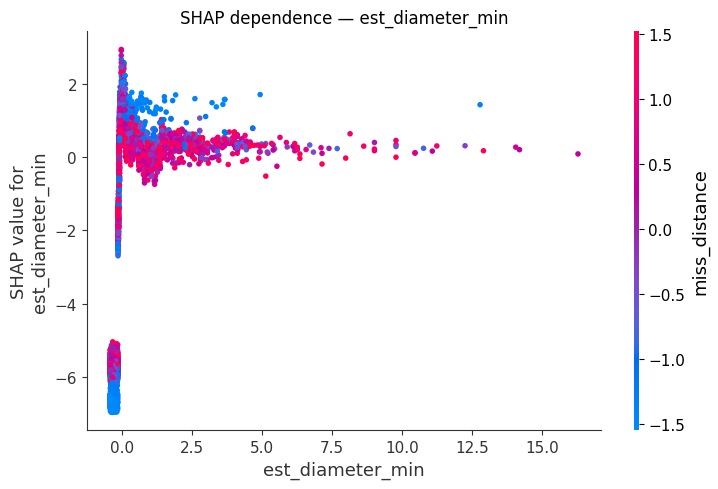

In [ ]:
# Dependence plot — most important feature
top_feature = FEATURES[np.abs(shap_values).mean(axis=0).argmax()]
print(f"Dependence plot for most important feature: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_test_df, show=False)
plt.title(f"SHAP dependence — {top_feature}")
plt.tight_layout()
plt.show()

## 12. Save model & scaler

In [ ]:
joblib.dump(best_xgb, "model.pkl")
joblib.dump(scaler,   "scaler.pkl")

print("Saved: model.pkl (XGBoost tuned)")
print("Saved: scaler.pkl")

In [ ]:
from google.colab import files
files.download("model.pkl")
files.download("scaler.pkl")

## 13. Quick inference test
Verify the saved model works before uploading to HuggingFace.

In [ ]:
import joblib
import numpy as np

m = joblib.load("model.pkl")
s = joblib.load("scaler.pkl")

# Example asteroid — small, slow, far away → should be NOT hazardous
sample = np.array([[0.1, 0.2, 5.0, 50_000_000, 28.0]])
prob   = m.predict_proba(s.transform(sample))[0][1]
print(f"Hazard probability: {prob*100:.1f}%  →  {'HAZARDOUS' if prob >= 0.5 else 'NOT HAZARDOUS'}")

# Example asteroid — large, fast, close → should be HAZARDOUS
sample2 = np.array([[2.5, 5.0, 60.0, 500_000, 15.0]])
prob2   = m.predict_proba(s.transform(sample2))[0][1]
print(f"Hazard probability: {prob2*100:.1f}%  →  {'HAZARDOUS' if prob2 >= 0.5 else 'NOT HAZARDOUS'}")